In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

df = pd.read_csv('data/cleaned_data.csv')
log_cols = [c for c in df.columns if c.endswith('_log')]

X = df[log_cols]
y = df['behavior_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_pipeline = Pipeline([
('scaler', StandardScaler()),
('rf', RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2


In [5]:
perm = permutation_importance(rf_pipeline, X_test, y_test, n_repeats=30, random_state=42)

perm_df = pd.DataFrame({
'variable': X.columns,
'importance_mean': perm.importances_mean,
'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)
perm_df

,variable,importance_mean,importance_std
1,IgE_IU_mL_log,0.220493,0.087061
2,IL4_pg_mL_log,0.076436,0.060695
4,IL10_pg_mL_log,0.052289,0.027663
0,IFNg_pg_mL_log,0.017472,0.020089
5,TNFa_pg_mL_log,-0.000266,0.023151
3,IL6_pg_mL_log,-0.055781,0.055445


In [6]:
import shap

explainer = shap.TreeExplainer(rf_pipeline.named_steps['rf'])
X_test_scaled = rf_pipeline.named_steps['scaler'].transform(X_test)
shap_values = explainer.shap_values(X_test_scaled)

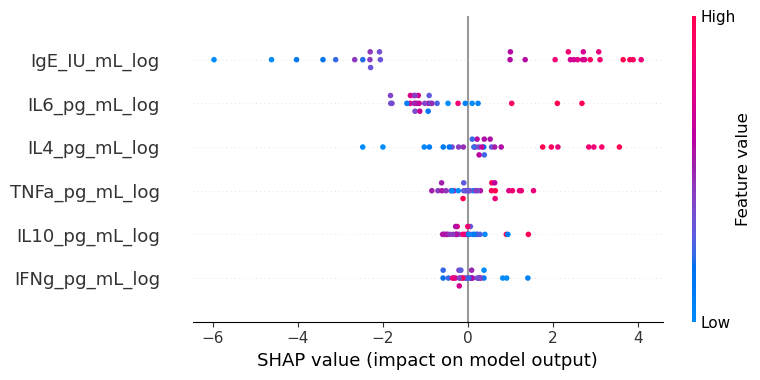

In [7]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

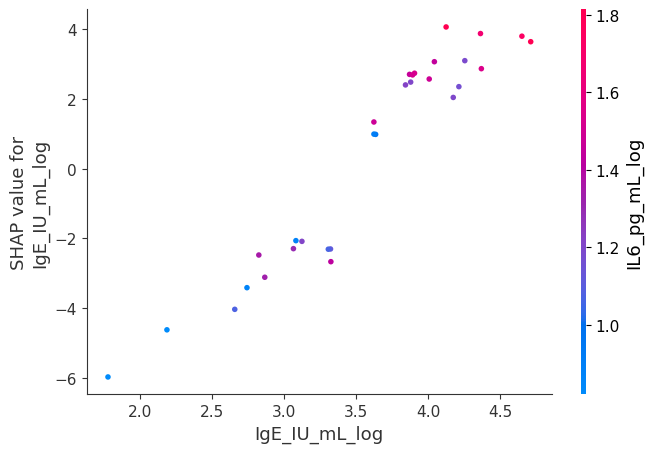

In [8]:
top_var = perm_df.iloc[0]['variable']
shap.dependence_plot(top_var, shap_values, X_test, feature_names=list(X.columns))

In [10]:
from sklearn.linear_model import LassoCV

X_scaled = StandardScaler().fit_transform(df[log_cols])
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

coef_table = pd.DataFrame({'variable': log_cols, 'lasso_coef': lasso.coef_}).sort_values('lasso_coef', key=abs, ascending=False)
coef_table

,variable,lasso_coef
1,IgE_IU_mL_log,2.816953
2,IL4_pg_mL_log,0.938859
4,IL10_pg_mL_log,0.355041
0,IFNg_pg_mL_log,0.000000
3,IL6_pg_mL_log,0.000000
5,TNFa_pg_mL_log,0.000000


In [11]:
# (paste in your lasso coef_table and results_df from earlier notebooks, or re-run those cells)

consensus = perm_df.merge(coef_table, on='variable', how='left')
consensus['flagged_by_lasso'] = consensus['lasso_coef'] != 0
consensus.sort_values('importance_mean', ascending=False)

,variable,importance_mean,importance_std,lasso_coef,flagged_by_lasso
0,IgE_IU_mL_log,0.220493,0.087061,2.816953,True
1,IL4_pg_mL_log,0.076436,0.060695,0.938859,True
2,IL10_pg_mL_log,0.052289,0.027663,0.355041,True
3,IFNg_pg_mL_log,0.017472,0.020089,0.000000,False
4,TNFa_pg_mL_log,-0.000266,0.023151,0.000000,False
5,IL6_pg_mL_log,-0.055781,0.055445,0.000000,False


In [14]:
from scipy import stats

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

df = pd.read_csv('data/cleaned_data.csv')
group_atypical = df[df['behavior_group']=='Atypical']['IgE_IU_mL_log']
group_typical = df[df['behavior_group']=='Typical']['IgE_IU_mL_log']

stat, pval = stats.mannwhitneyu(group_atypical, group_typical)
d = cohens_d(group_atypical, group_typical)
print(f"Mann-Whitney p={pval:.4f}, Cohen's d={d:.2f}")

Mann-Whitney p=0.0000, Cohen's d=0.88
